<a href="https://colab.research.google.com/github/tungduong2106/PracticeML/blob/main/Practice_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import matplotlib as plt
import numpy as np
import pandas as pd

from sklearn import datasets, linear_model
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error

In [2]:
# Lấy dữ liệu
diabetes = datasets.load_diabetes()
print("Số chiều dữ liệu input: ", diabetes.data.shape)
print("Kiểu dữ liệu input: ", type(diabetes.data))
print("Số chiều dữ liệu target: ", diabetes.target.shape)
print("Kiểu dữ liệu target: ", type(diabetes.target))
print()

print("5 mẫu dữ liệu đầu tiên:")
print("input: ", diabetes.data[:5])
print("input: ", diabetes.target[:5])

Số chiều dữ liệu input:  (442, 10)
Kiểu dữ liệu input:  <class 'numpy.ndarray'>
Số chiều dữ liệu target:  (442,)
Kiểu dữ liệu target:  <class 'numpy.ndarray'>

5 mẫu dữ liệu đầu tiên:
input:  [[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]
input:  [151.  75. 141. 206. 135.]


In [3]:
print(diabetes.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [4]:
# Chia train và test cho dữ liệu
diabetes_X = diabetes.data

diabetes_X_train = diabetes_X[:361]
diabetes_Y_train = diabetes.target[:361]

diabetes_X_test = diabetes_X[362:]
diabetes_Y_test = diabetes.target[362:]

In [5]:
regr = linear_model.LinearRegression()

In [6]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha = 0.1)

In [7]:
# Huấn luyện mô hình Linear
regr.fit(diabetes_X_train, diabetes_Y_train)
print("[w1,....w_n] = ",regr.coef_)
print("w0 = ",regr.intercept_)

[w1,....w_n] =  [-1.12982324e-02 -2.49782541e+02  5.18802202e+02  2.97220454e+02
 -6.39802236e+02  3.56330510e+02  2.77834385e+01  1.46962789e+02
  6.90474996e+02  1.05716702e+02]
w0 =  152.56041961097782


In [8]:
# Ridge model
ridge.fit(diabetes_X_train, diabetes_Y_train)
print("[w1,....w_n] = ",ridge.coef_)
print("w0 = ",ridge.intercept_)

[w1,....w_n] =  [  10.51523842 -215.21946642  477.04576811  275.18547584  -64.84522547
  -82.84458659 -194.22465786  112.99561167  427.19001456  121.18397114]
w0 =  152.57401415344637


In [9]:
#Giá trị đúng
print("Gia tri true: ",diabetes_Y_test[0])
x = diabetes_X_test[0]
#Linear
Y_pred_linear = regr.predict(diabetes_X_test[0:1])
print("Gia tri du doan cho mo hinh linear regression: ",Y_pred_linear)
y_manual = regr.intercept_ + (regr.coef_ * x).sum()
print("Gia tri du doan tinh bang cong thuc Linear Regression:", y_manual)
#Ridge
Y_pred_ridge = ridge.predict(diabetes_X_test[0:1])
print("Gia tri du doan cho mo hinh ridge regression: ",Y_pred_ridge)
y_manual_ridge = ridge.intercept_ + (ridge.coef_ * x).sum()
print("Gia tri du doan tinh bang cong thuc Ridge Regression:", y_manual_ridge)

Gia tri true:  321.0
Gia tri du doan cho mo hinh linear regression:  [234.35947872]
Gia tri du doan tinh bang cong thuc Linear Regression: 234.35947872322686
Gia tri du doan cho mo hinh ridge regression:  [226.73474004]
Gia tri du doan tinh bang cong thuc Ridge Regression: 226.73474004055703


In [10]:
diabetes_y_pred = regr.predict(diabetes_X_test)
pd.DataFrame(data=np.array([diabetes_Y_test, diabetes_y_pred,abs(diabetes_Y_test-diabetes_y_pred)]).T,columns=["Thực tế", "Dự đóan", "Lệch"])

,Thực tế,Dự đóan,Lệch
0,321.0,234.359479,86.640521
1,58.0,163.999748,105.999748
2,262.0,163.520115,98.479885
3,206.0,167.189446,38.810554
4,233.0,254.806697,21.806697
...,...,...,...
75,178.0,191.710701,13.710701
76,104.0,104.626354,0.626354
77,132.0,122.693494,9.306506
78,220.0,210.454911,9.545089


In [11]:
# RMSE của Linear
print(math.sqrt(mean_squared_error(diabetes_Y_test, diabetes_y_pred)))
# r2 của Linear
print(r2_score(diabetes_Y_test,diabetes_y_pred))

51.53921127468042
0.5631505527533232


In [12]:
_lambda = [0, 0.0001, 0.01, 0.04, 0.05, 0.06, 0.1, 0.5, 1, 5, 10, 20]
result = []
for l in _lambda:
    model = Ridge(alpha=l)
    # Huấn luyện
    model.fit(diabetes_X_train, diabetes_Y_train)
    # Dự đoán
    Y_predd = model.predict(diabetes_X_test)
    rmse = math.sqrt(mean_squared_error(diabetes_Y_test, Y_predd))
    r2=r2_score(diabetes_Y_test,Y_predd)
    result.append(rmse)
    print(f"{l:10g} | {rmse:10.4f} | {r2:10.4f}")

         0 |    51.5392 |     0.5632
    0.0001 |    51.5464 |     0.5630
      0.01 |    51.8887 |     0.5572
      0.04 |    52.1121 |     0.5534
      0.05 |    52.1525 |     0.5527
      0.06 |    52.1908 |     0.5520
       0.1 |    52.3476 |     0.5493
       0.5 |    54.6133 |     0.5095
         1 |    57.3826 |     0.4585
         5 |    67.2413 |     0.2564
        10 |    71.1874 |     0.1666
        20 |    74.0574 |     0.0980


,values
count,80.00000
mean,152.38750
std,78.46994
min,40.00000
25%,72.00000
50%,140.00000
75%,217.50000
max,321.00000


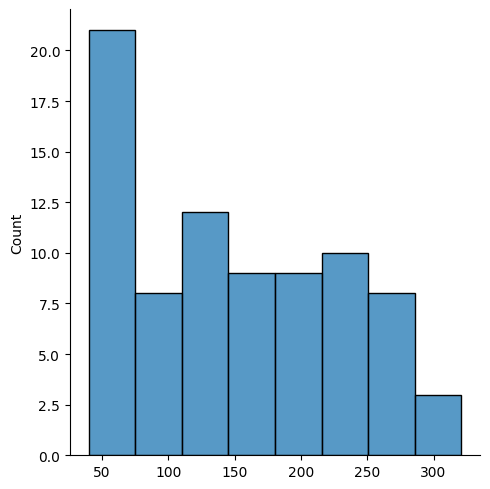

In [13]:
import seaborn as sns
sns.displot(diabetes_Y_test)
pd.DataFrame(data=diabetes_Y_test, columns=["values"]).describe()

,values
count,80.000000
mean,155.501049
std,57.511599
min,49.193721
25%,112.399159
50%,161.143223
75%,191.047878
max,279.598577


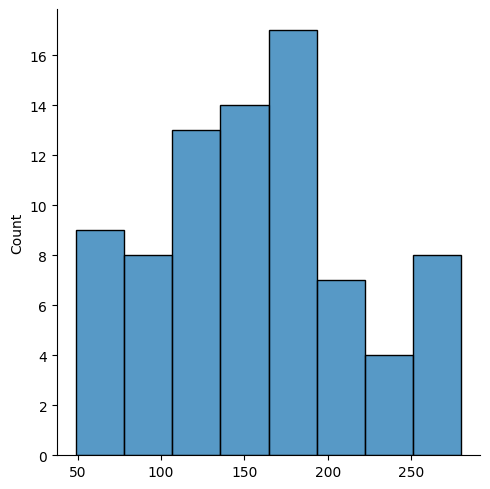

In [14]:
import seaborn as sns
sns.displot(diabetes_y_pred)
pd.DataFrame(data=diabetes_y_pred, columns=["values"]).describe()

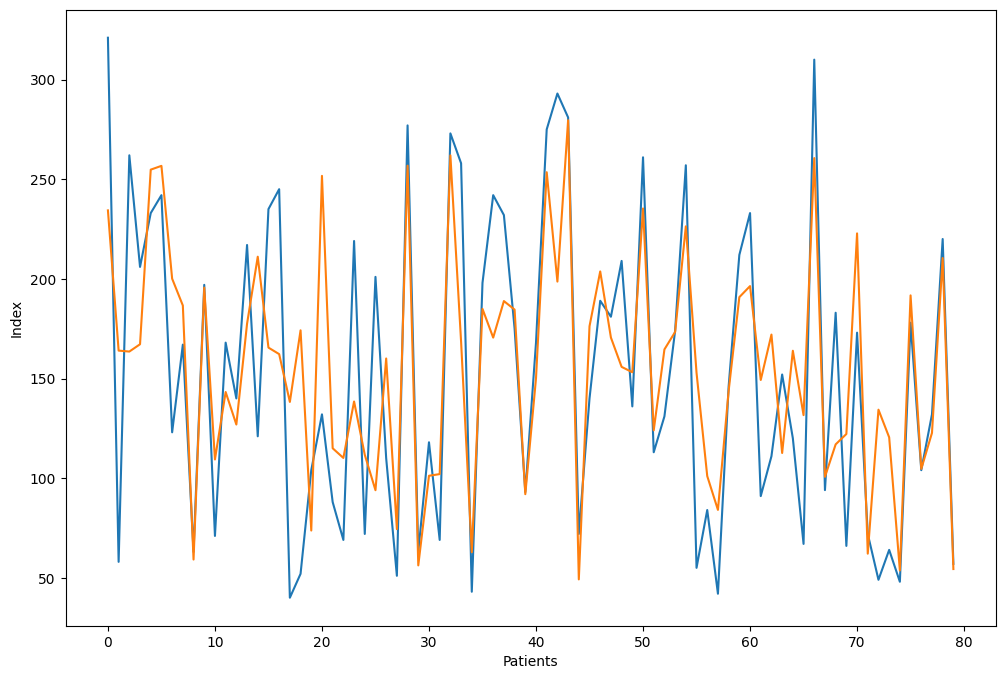

In [15]:
# Bieu do so sanh ket qua du doan va thuc te
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.plot(diabetes_Y_test)
plt.plot(diabetes_y_pred)

plt.xlabel('Patients')
plt.ylabel('Index')

plt.show()